In [18]:
import pandas as pd
import numpy as np

import load.load_dataset as ds

import seaborn as sns
import matplotlib.pyplot as plt

import os
import joblib

import torch
import torch.nn as nn

from captum.attr import IntegratedGradients, DeepLift
from utils.lrp import LRP, linear_rule, non_linear_support
from captum.attr._utils.lrp_rules import GammaRule
import load.load_dataset as ds
from load import load_net

import warnings
warnings.filterwarnings('ignore')
np.random.seed(0)

Are attribution of the points identical between methods? they should be since neighbour affects robustness, and attributions are computed before robustness

In [19]:
results = {}

for dataset in ["adult", "bank", "beans", "cancer", "heloc", "mushroom", "ocean", "wine"]:
    for model in ["model1", "model2", "model3", "model1r", "model2r", "model3r"]:
        for tv in ["validation", "test"]:
            for idx, method in enumerate(["ig", "dl", "lrp"]):
                A = os.path.join(os.getcwd(), "results_medoid", f"{dataset}_{model}", f"{tv}", "attributions.npy")
                B = os.path.join(os.getcwd(), "results_random", f"{dataset}_{model}", f"{tv}", "attributions.npy")
                A = np.load(A)
                B = np.load(B)
                A = A[:, 0, :, idx] # keep only attribution of the point, remove neighbours
                B = B[:, 0, :, idx]
                div = np.sum(~np.isclose(A, B, atol=1e-6))
                results[(dataset, model, tv, method)] = div

In [20]:
df = pd.Series(results).reset_index()
df.columns = ['Dataset', 'Model', 'Split', 'Method', 'Differences']

df_ig = df[df['Method'] == 'dl']

pivot_ig = df_ig.pivot(index=['Dataset', 'Split'], columns='Model', values='Differences')
pivot_df = df.pivot(index=['Dataset', 'Split'], columns=['Method', 'Model'], values='Differences')

print(pivot_df)

Method                  ig      dl    lrp     ig      dl    lrp     ig  \
Model               model1  model1 model1 model2  model2 model2 model3   
Dataset  Split                                                           
adult    test            0   11764      0      7    5256      0      0   
         validation      0   94186      0      4   39970     12      0   
bank     test            0   13802      0      0   13971     14      0   
         validation      0  110912      0      0  112343     14      0   
beans    test            0    3241      0      0    3152      0      0   
         validation      7   14390      7     14   13942     14      0   
cancer   test            0     740      0     15     737     15      0   
         validation      0    1799      0      0    1805      0     15   
heloc    test            0    6032      0      0    6579      0      0   
         validation      0   19298      0      0   20675      0      0   
mushroom test            0    8351    

deeplift non produce feature attribution consistenti quando viene calcolato su un punto e quando viene calcolato su un batch punto con la sua neighbourhood

# verify difference

In [22]:
# test su cancer:
# model 4 e model5 sono identici a differenza delle dim di softmax = 1 per model5 vs None per model4
results = {}

for dataset in ["cancer", "wine"]:
    for model in ["model1", "model4", "model5"]:
        for tv in ["validation"]:
            for idx, method in enumerate(["ig", "dl", "lrp"]):
                A = os.path.join(os.getcwd(), "results_medoid", f"{dataset}_{model}", f"{tv}", "attributions.npy")
                B = os.path.join(os.getcwd(), "results_random", f"{dataset}_{model}", f"{tv}", "attributions.npy")
                A = np.load(A)
                B = np.load(B)
                A = A[:, 0, :, idx] # keep only attribution of the point, remove neighbours
                B = B[:, 0, :, idx]
                div = np.sum(~np.isclose(A, B, atol=1e-6))
                results[(dataset, model, method)] = div

In [24]:
df = pd.Series(results).reset_index()
df.columns = ['Dataset', 'Model', 'Method', 'Differences']

df_ig = df[df['Method'] == 'dl']

pivot_ig = df_ig.pivot(index=['Dataset'], columns='Model', values='Differences')
pivot_df = df.pivot(index=['Dataset'], columns=['Method', 'Model'], values='Differences')

print(pivot_ig)

# different results

Model    model1  model4  model5
Dataset                        
cancer     1799    1784    1784
wine       2183    4397    4397


In [4]:
dataset = "adult"
model_name = "model1"
type = "test"
idx = 222
pad_sizes = [0, 10, 100]
seed = 0
atol = 1e-6

prova su padded batch

In [5]:
np.random.seed(seed)
torch.manual_seed(seed)

net = load_net.load_net(dataset)
dataset = ds.Dataset(dataset)

X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()

model = dataset.load_model(model_name)

import copy
model_dl = copy.deepcopy(model)
model_dl.softmax = nn.Identity()
dl = DeepLift(model_dl)

model.eval()
model.softmax.dim = 1

data_tensor = X_val if type == "validation" else X_test

row = data_tensor[idx, :].unsqueeze(0)
target = int(np.argmax(model(row).detach().numpy()))
print(f"[{dataset} / {model_name} / {type}] idx={idx}  predicted target class={target}")

pool_idx = [i for i in range(data_tensor.shape[0]) if i != idx]

ig = IntegratedGradients(model)

lrp_model = model
lrp = LRP(lrp_model)
_ = linear_rule(GammaRule)
_ = non_linear_support(nn.Softmax)
_ = non_linear_support(nn.Identity)


def compute_row0_attrs(batch):
    batch = batch.clone().detach().requires_grad_()

    ig_attr = ig.attribute(batch, target=target).detach().numpy()[0]
    dl_attr = dl.attribute(batch, target=target).detach().numpy()[0]

    lrp_raw = lrp.attribute(batch, target=target).detach().numpy()
    output_score = lrp_model(batch).detach().numpy()[:, target]
    lrp_attr = (lrp_raw * output_score[:, np.newaxis])[0]

    return {"ig": ig_attr, "dl": dl_attr, "lrp": lrp_attr}


results = {}
for pad in pad_sizes:
    if pad == 0:
        batch = row.clone()
    else:
        extra_idx = np.random.choice(pool_idx, size=pad, replace=False)
        batch = torch.cat([row, data_tensor[extra_idx, :]], dim=0)

    results[pad] = compute_row0_attrs(batch)
    print(f"  computed batch size {batch.shape[0]} (pad={pad})")

print()
base_pad = pad_sizes[0]
base = results[base_pad]
for pad in pad_sizes[1:]:
    other = results[pad]
    for method in ["ig", "dl", "lrp"]:
        identical = np.allclose(base[method], other[method], atol=atol)
        max_diff = np.max(np.abs(base[method] - other[method]))
        n_diff = np.sum(~np.isclose(base[method], other[method], atol=atol))
        print(f"{method.upper():4s}  pad={base_pad:>4d} vs pad={pad:>4d}  "
              f"identical={str(identical):5s}  max_abs_diff={max_diff:.6g}  "
              f"n_entries_diff={n_diff}/{base[method].shape[0]}")


[<load.load_dataset.Dataset object at 0x1210c1730> / model1 / test] idx=222  predicted target class=0
  computed batch size 1 (pad=0)
  computed batch size 11 (pad=10)
  computed batch size 101 (pad=100)

IG    pad=   0 vs pad=  10  identical=True   max_abs_diff=1.19209e-06  n_entries_diff=0/97
DL    pad=   0 vs pad=  10  identical=False  max_abs_diff=0.00012207  n_entries_diff=1/97
LRP   pad=   0 vs pad=  10  identical=True   max_abs_diff=8.9407e-08  n_entries_diff=0/97
IG    pad=   0 vs pad= 100  identical=True   max_abs_diff=1.19209e-06  n_entries_diff=0/97
DL    pad=   0 vs pad= 100  identical=False  max_abs_diff=0.00012207  n_entries_diff=1/97
LRP   pad=   0 vs pad= 100  identical=True   max_abs_diff=1.19209e-07  n_entries_diff=0/97


# reg vs not

In [6]:
model_list = ['model1', 'model2', 'model3']
dataset_name = "bank"

neigh = "medoid" # medoid random
set_type = "validation" # validation test

methods_labels = ["IG", "DL", "LRP"] #"ensemble"

folder = os.path.join(os.getcwd(), f"results_{neigh}")

In [7]:
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal,discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()

print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(36168, 14) (8043, 14) (1000, 14)


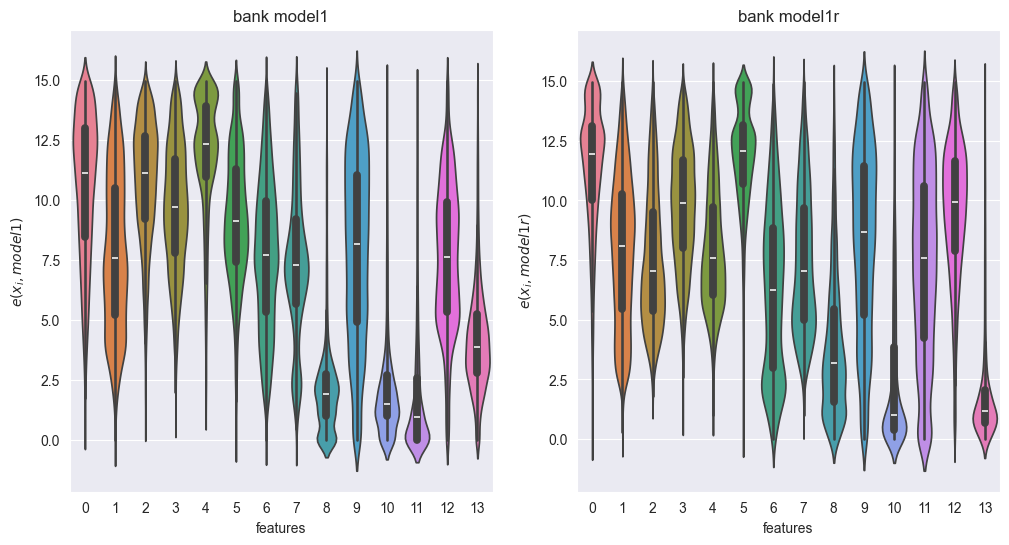

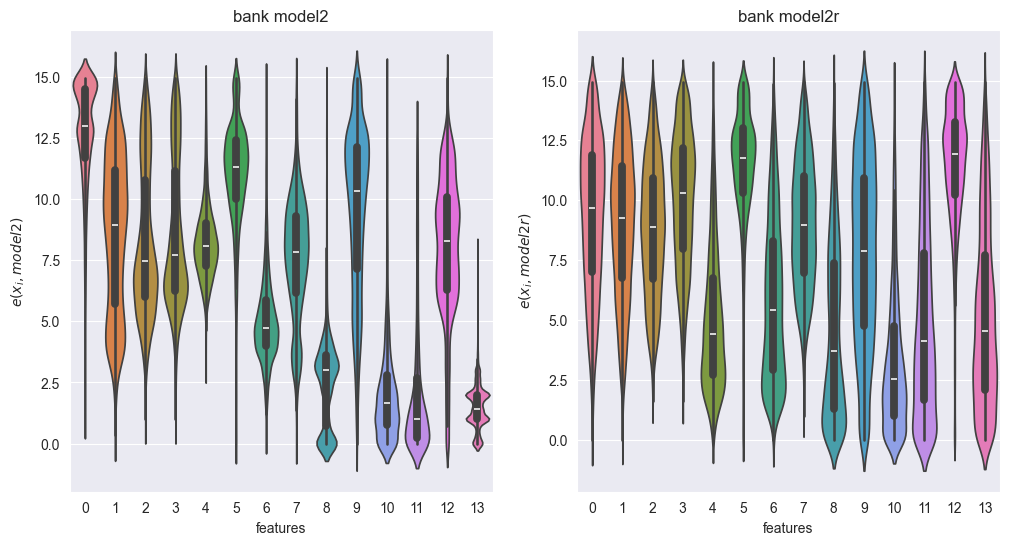

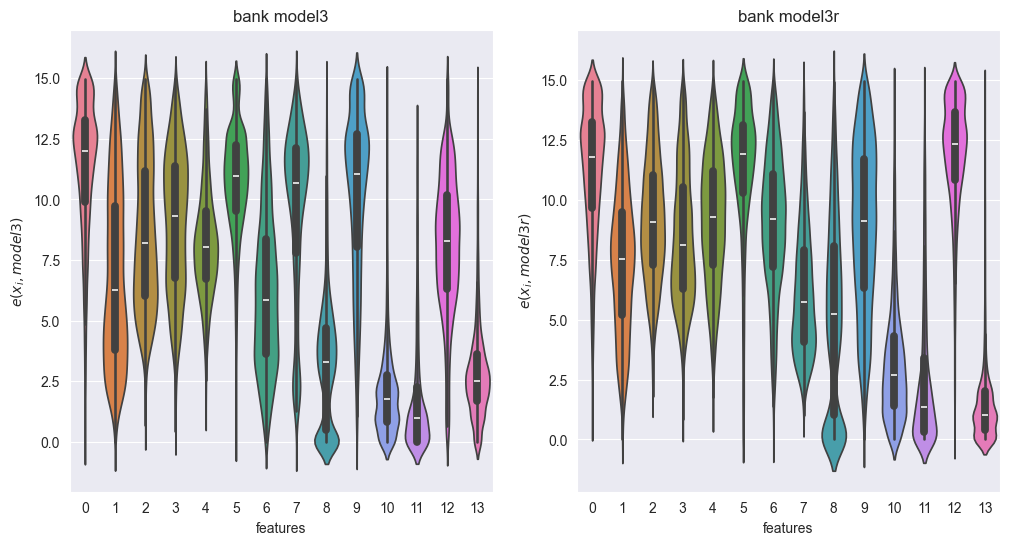

In [8]:
for model_name in model_list:
    folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")
    folder_reg = os.path.join(folder, f"{dataset_name}_{model_name}r")

    att_m = np.load(os.path.join(folder_, f"{set_type}", "ensemble.npy"))
    att_reg = np.load(os.path.join(folder_reg, f"{set_type}", "ensemble.npy"))

    #att_m = np.log(att_m)
    #att_reg = np.log(att_reg)
    fig, ax = plt.subplots(1,2, figsize=(12,6))

    df_att_m = pd.DataFrame(att_m[:,0,:])
    df_att_reg = pd.DataFrame(att_reg[:,0,:])

    sns.violinplot(data=df_att_m, ax=ax[0])
    sns.violinplot(data=df_att_reg,ax=ax[1])

    ax[0].set_title(f"{dataset_name} {model_name}")
    ax[1].set_title(f"{dataset_name} {model_name}r")
    ax[0].set_xlabel("features")
    ax[1].set_xlabel("features")
    ax[0].set_ylabel(f"$e(x_i, {model_name})$")
    ax[1].set_ylabel(f"$e(x_i, {model_name}r)$")
    plt.show()

## Variance analysis

In [9]:
variance_vec = []

for model_name in model_list:
    folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")
    folder_reg = os.path.join(folder, f"{dataset_name}_{model_name}r")

    att_m = np.load(os.path.join(folder_, f"{set_type}", "ensemble.npy"))
    att_reg = np.load(os.path.join(folder_reg, f"{set_type}", "ensemble.npy"))

    # FOR ENSEMBLE
    att_m = att_m[:, 0, :]
    att_reg = att_reg[:, 0, :]

    # FOR SINGLE METHOD ATTRIBUTIONS
    """att_m = att_m[:, 0, :, 2]
    att_reg = att_reg[:, 0, :, 2]"""

    #print(att_reg.shape)

    att_m = np.abs(att_m)
    att_m = att_m / att_m.sum(axis=1, keepdims=True)
    variance_m = att_m.var(axis=1)

    att_reg = np.abs(att_reg)
    att_reg = att_reg / att_reg.sum(axis=1, keepdims=True)
    variance_reg = att_reg.var(axis=1)

    variance_vec.append([variance_m, variance_reg])


In [10]:
for i, model_name in enumerate(model_list):
    variance_m, variance_reg = variance_vec[i]
    print(f"\n  {model_name}")
    print(f"non reg Average         {np.average(variance_m)}")
    #print(f"non reg median          {np.median(variance_m)}")
    print(f"regularized Average     {np.average(variance_reg)}")
    #print(f"regularized median      {np.median(variance_reg)}")


  model1
non reg Average         0.0018091551465061668
regularized Average     0.0015943436553111706

  model2
non reg Average         0.0019591309914998205
regularized Average     0.0015150214519099143

  model3
non reg Average         0.0018526199080388728
regularized Average     0.00165865246508063


Il vettore ottenuto ha dimensione 8043, per ogni input è misurata la varianza nel suo feature attribution vector

La media (per input) della varianza è sempre più alta nei modelli non regolarizzati, significa che le feature attribution dei modelli regolarizzati sono più uniformi.

Inoltre la mediana coincide con la media quindi (i punti estremi non influenziano di molto la media ???)

In [11]:
for i, model_name in enumerate(model_list):
    variance_m, variance_reg = variance_vec[i]
    print(f"\n  {model_name}")
    print(np.mean(variance_m > variance_reg))


  model1
0.7990799452940445

  model2
0.9005346263831904

  model3
0.7955986572174562


percentuale di input in cui le feature attribution del modello regolarizzato sono più concentrate rispetto a quelle del modello regolarizzato

si può notare che nell'80/90 % degli input il modello regolarizzato ha feature attribution più piatte

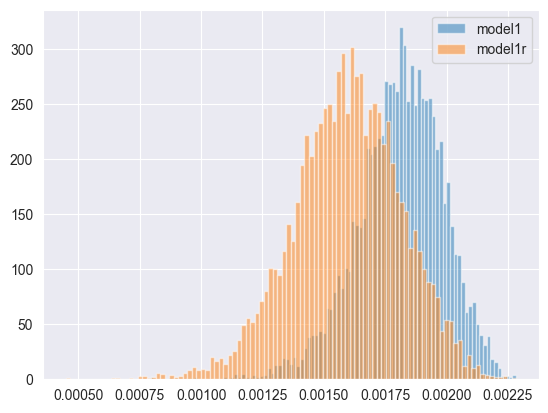

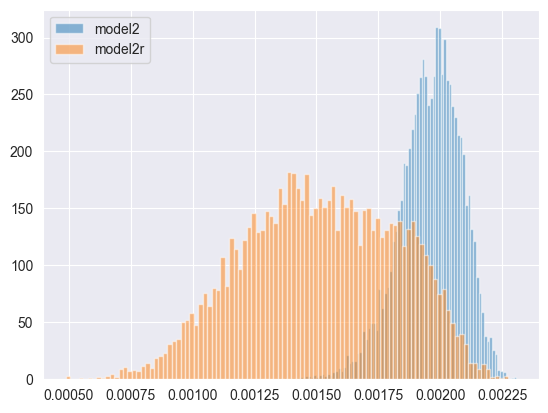

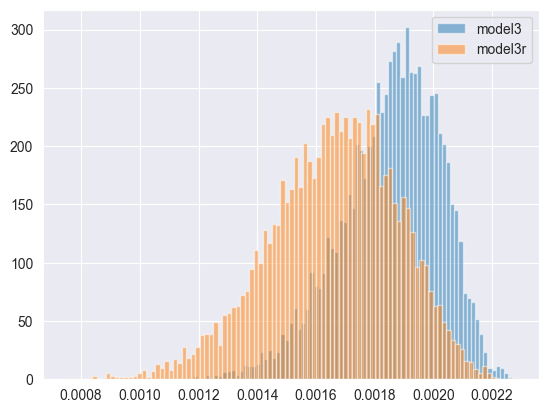

In [12]:
for i, model_name in enumerate(model_list):
    variance_m, variance_reg = variance_vec[i]
    plt.hist(variance_m, bins=100, alpha=0.5, label=f"{model_name}")
    plt.hist(variance_reg, bins=100, alpha=0.5, label=f"{model_name}r")
    plt.legend(); plt.show()

plotting the distribution: the mean variance is different, vairances are distributed differently

le varianze de modelli regolarizzati sono sistematicamente più basse, più vicine allo zero

<b>QUESTO SUCCEDE PRATICAMENTE SOLO SU BANK, CHE INFATTI è IL DATASET CHE PIù DROPPA IN ROBUSTEZZA DELLA SPIEGAZIONE</b>

## Entropy analysis

In [13]:
entropy_vec = []

for model_name in model_list:
    folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")
    folder_reg = os.path.join(folder, f"{dataset_name}_{model_name}r")

    att_m = np.load(os.path.join(folder_, f"{set_type}", "ensemble.npy"))
    att_reg = np.load(os.path.join(folder_reg, f"{set_type}", "ensemble.npy"))

    # FOR ENSEMBLE
    att_m = att_m[:, 0, :]
    att_reg = att_reg[:, 0, :]

    # FOR SINGLE METHOD ATTRIBUTIONS
    """att_m = att_m[:, 0, :, 2]
    att_reg = att_reg[:, 0, :, 2]"""

    eps = 1e-12

    att_m = np.abs(att_m)
    att_m = att_m / (att_m.sum(axis=1, keepdims=True) + eps)

    entropy_m = -(att_m * np.log(att_m + eps)).sum(axis=1)
    entropy_m_norm = entropy_m / np.log(att_m.shape[1])
    eff_features_m = np.exp(entropy_m)

    #print(eff_features_m.shape)

    att_reg = np.abs(att_reg)
    att_reg = att_reg / (att_reg.sum(axis=1, keepdims=True) + eps)

    entropy_reg = -(att_reg * np.log(att_reg + eps)).sum(axis=1)
    entropy_reg_norm = entropy_reg / np.log(att_reg.shape[1])
    eff_features_reg = np.exp(entropy_reg)

    entropy_vec.append([entropy_m_norm, entropy_reg_norm])


In [14]:
for i, model_name in enumerate(model_list):
    entropy_m, entropy_reg = entropy_vec[i]
    print(f"\n  {model_name}")
    print(f"non reg average norm Entropy        {np.mean(entropy_m)}")
    print(f"regularized average norm Entropy    {np.mean(entropy_reg)}")


  model1
non reg average norm Entropy        0.9177944240736412
regularized average norm Entropy    0.9279459555019475

  model2
non reg average norm Entropy        0.9126048676218359
regularized average norm Entropy    0.9326569259623386

  model3
non reg average norm Entropy        0.9166522773872436
regularized average norm Entropy    0.9232446655339859


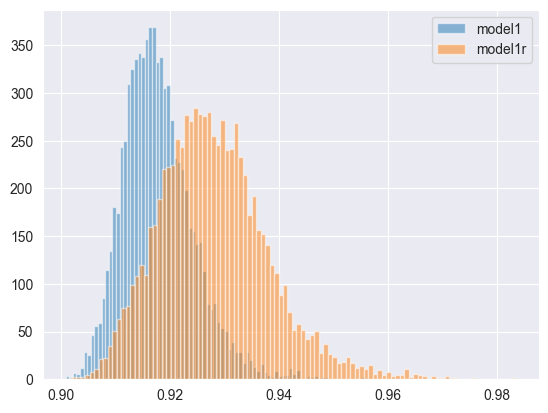

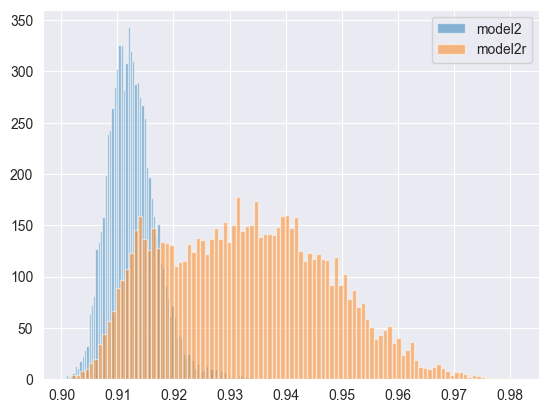

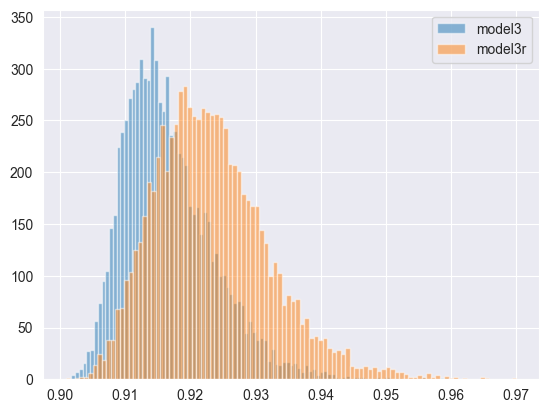

In [15]:
for i, model_name in enumerate(model_list):
    entropy_m, entropy_reg = entropy_vec[i]
    plt.hist(entropy_m, bins=100, alpha=0.5, label=f"{model_name}")
    plt.hist(entropy_reg, bins=100, alpha=0.5, label=f"{model_name}r")
    plt.legend(); plt.show()

Anche in questo caso, come nell'analisi della varianza l'entropia dei modelli regolarizzati è sistematicamente più alta, questo vuol dire che le feature attribution generate da modelli regolarizzati sono (di poco) più unformi, ovvero nel caso di bank sono tutti più simili a [1/14, 1/14, ... 1/14]